In [13]:
import torch
import matplotlib.pyplot as plt 
import seaborn as sns

In [14]:
def no_randomness():
    torch.manual_seed(31)

In [15]:
no_randomness()
inputs = torch.randn(1, 100, 768)
inputs.shape

torch.Size([1, 100, 768])

In [16]:
no_randomness()


class LayerNorm(torch.nn.Module):
    def __init__(self, d_out):
        super().__init__()
        self.eps = 1e-5
        self.scale = torch.nn.Parameter(torch.ones(d_out))
        self.shift = torch.nn.Parameter(torch.zeros(d_out))

    def forward(self, x):
        # x = (x - x.mean(dim=-1, keepdims=True)) / x.std(dim=-1, keepdims=True)
        x = (x - x.mean(dim=-1, keepdims=True)) / (
            torch.sqrt(x.var(dim=-1, keepdims=True, correction=0) + self.eps)
        )
        return self.scale * x + self.shift


print(inputs.mean(dim=-1), inputs.std(dim=-1))
ln_out = LayerNorm(inputs.shape[-1])(inputs)
print(ln_out.mean(dim=-1), ln_out.std(dim=-1, correction=0))

tensor([[ 3.2250e-02, -1.5878e-02,  1.6481e-02,  7.3729e-02,  3.8223e-02,
         -4.9380e-02,  4.7102e-02, -2.8196e-02, -3.0910e-02,  1.1832e-02,
         -4.7112e-03, -1.8363e-02,  2.9827e-02, -3.6339e-02, -6.6401e-03,
          3.3852e-02,  2.2679e-02, -3.2870e-02, -1.4895e-02, -4.5343e-03,
         -2.1464e-02,  2.9335e-02,  2.3478e-02, -2.9500e-02, -1.2078e-02,
         -1.4332e-02, -1.1257e-02,  2.7071e-02, -1.7700e-02, -1.0903e-03,
         -4.7758e-02, -2.3928e-02, -1.3224e-02,  3.8622e-02,  7.5940e-02,
          7.3689e-05,  3.5473e-02,  1.0166e-02,  2.9416e-02, -2.2669e-02,
          3.3880e-02, -1.4949e-02,  6.8372e-02,  3.3029e-02,  1.3711e-02,
         -3.4237e-02,  3.2845e-02, -1.0056e-02, -9.1914e-02, -4.5834e-02,
         -2.6884e-03, -3.1248e-02, -1.7330e-02,  3.1009e-02, -4.7228e-02,
          4.5524e-02, -2.4233e-02, -7.6940e-03,  1.7474e-02, -1.4487e-02,
         -2.3987e-03, -3.1084e-02, -4.4997e-03,  2.3328e-02,  4.9527e-02,
         -3.7996e-02, -1.1505e-02,  1.

In [21]:
no_randomness()


class MultiHeadAttention(torch.nn.Module):

    def __init__(
        self,
        emb_size,
        hidden_dim,
        num_heads,
        context_len,
        dropout_p=0.2,
        qkv_bias=False,
    ):
        super().__init__()
        assert (
            hidden_dim % num_heads == 0
        ), "Number of Heads should be divisible to the hidden dims"
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads
        # print(self.num_heads, self.head_dim)
        self.WQ = torch.nn.Linear(emb_size, hidden_dim, bias=qkv_bias)
        self.WK = torch.nn.Linear(emb_size, hidden_dim, bias=qkv_bias)
        self.WV = torch.nn.Linear(emb_size, hidden_dim, bias=qkv_bias)
        self.DO = torch.nn.Dropout(dropout_p)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_len, context_len), diagonal=1)
        )

    def forward(self, x):
        batch_size, num_tokens, emb_size = x.shape
        Q = self.WQ(x)
        K = self.WK(x)
        V = self.WV(x)
        # print(Q.shape, K.shape, V.shape)

        # add heads
        Qh = Q.view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(
            1, 2
        )
        Kh = K.view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(
            1, 2
        )
        Vh = V.view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(
            1, 2
        )

        # print(Qh.shape, Kh.shape, Vh.shape)

        atten_score = Qh @ Kh.transpose(2, 3)
        # print(atten_score.shape)
        atten_score.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        atten_score = self.DO(torch.softmax(atten_score, dim=-1))
        CTXh = (atten_score @ Vh).transpose(1, 2)
        CTX = CTXh.contiguous().view(batch_size, num_tokens, emb_size)
        return CTX


mha = MultiHeadAttention(
    emb_size=inputs.shape[-1],
    hidden_dim=inputs.shape[-1],
    num_heads=8,
    context_len=128,
    dropout_p=0,
)(inputs)
mha_ln = LayerNorm(inputs.shape[-1])(mha)

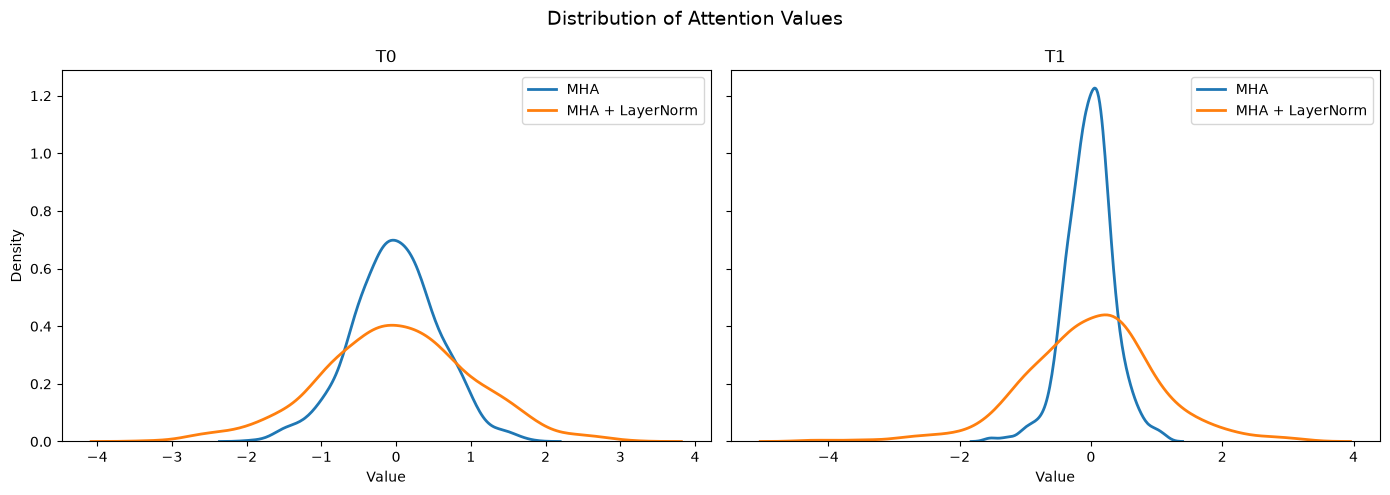

In [22]:
x1 = mha.squeeze()[0].detach().cpu().numpy()
x2 = mha_ln.squeeze()[0].detach().cpu().numpy()
x3 = mha.squeeze()[-1].detach().cpu().numpy()
x4 = mha_ln.squeeze()[-1].detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: T05
sns.kdeplot(x1, linewidth=2, label="MHA", ax=axes[0])
sns.kdeplot(x2, linewidth=2, label="MHA + LayerNorm", ax=axes[0])
axes[0].set_title("T0")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].legend()

# Right: T95
sns.kdeplot(x3, linewidth=2, label="MHA", ax=axes[1])
sns.kdeplot(x4, linewidth=2, label="MHA + LayerNorm", ax=axes[1])
axes[1].set_title(f"T{len(mha_ln)}")
axes[1].set_xlabel("Value")
axes[1].legend()

plt.suptitle("Distribution of Attention Values", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
x1.mean(), x1.std()

(np.float32(0.098419294), np.float32(0.6329812))

In [20]:
x2.mean(), x2.std()

(np.float32(-5.9604643e-10), np.float32(0.9999874))